# MPLAVP Tutorial

This tutorial demonstrates how to use **MPLAVP** to retrieve aerosol vertical profiles (AVP) based on TRACER data.

- **Example 1** shows how to retrieve AVP using **ARM AMF-1** data.
- **Example 2** demonstrates retrieval using **TAMU** data.
- **Example 3** code and example for batch processing.

Typically, batch processing is used to handle large volumes of data efficiently. However, working through Example 1 and Example 2 is highly recommended, as they will help you understand how MPLAVP works and enable you to write additional code if the data source changes or adopts a new format.

Please refer to the documentation and code comments for additional information.


## Example 1: Retrieve Aerosol Vertical Profile (AVP) using the TRACER ARM AMF-1 data

**MPLAVP** is a procedure that mainly consists of several key steps:

- Read and process MPL data (initial corrections, calculating NRB, interpolation, cloud masking)  
- Read radiosonde data and calculate the Rayleigh backscatter profile  
- Perform Fernald retrieval using the MPL NRB profile and Rayleigh backscatter profile to generate the aerosol backscatter coefficient  
- Read aerosol size distribution and concentration data  
- Read or calculate hygroscopic kappa\*, and use kappa and the radiosonde RH profile to correct the aerosol backscatter coefficient profile to a dry aerosol backscatter coefficient profile  
- Use the total concentration (by integrating the aerosol size distribution) to linearly scale the dry aerosol backscatter coefficient profile to obtain the aerosol vertical profile.

\*Kappa can be inferred using ACSM, HTDMA, or the combination of aerosol size distribution and CCN data. Since ARM AMF-1 CCN data had an issue during TRACER and is not usable, we demonstrate the retrieval here using TRACER ACSM kappa provided by Dr. Maria Zawadowicz (DOE).

In this tutorial, we primarily call functions from the tracer_avp_processing module, which contains the main logic for each individual processing step. This module interfaces directly with the pympl, plotmpl, inversempl, and retrieval_aux modules. You will not need to interact with pympl, plotmpl, inversempl, or retrieval_aux directly during this tutorial.

The pympl, plotmpl, and inversempl modules handle the core processing and visualization of MPL data. The retrieval_aux module provides auxiliary functions for reading data from various instruments and managing supporting datasets. Some functions in retrieval_aux are legacy or intended for testing, though you may find them useful. This module also serves as a place to add future helper functions as needed.

In [22]:
# import necessary python packages

import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import tracer_avp_processing
from pathlib import Path

In [23]:
# Initialize the data directory path. 
# Modify these paths as needed to point to your local data.

# ── Define project root ────────────────────────────────────────────────
# Adjust the `.parent` chain if your script lives at a different depth.
SCRIPT_DIR   = SCRIPT_DIR = Path.cwd().resolve()        # /…/mplavp/dev
PROJECT_ROOT = SCRIPT_DIR.parent                        # /…/mplavp

# ── Data & output folders (all under PROJECT_ROOT) ─────────────────────
EXAMPLE_DATA = PROJECT_ROOT / "example_data"
OUTPUT_DIR   = PROJECT_ROOT / "example_output"

# ── ARM MPL raw data & calibration files ───────────────────────────────
arm_mpl_dir_path                = EXAMPLE_DATA / "arm_mpl"

arm_mpl_calib_dir               = EXAMPLE_DATA / "arm_mpl_calibration"
arm_mpl_afterpulse_binary_path  = arm_mpl_calib_dir / "MPL107_Afterpulse_201911080400.bin"
arm_mpl_overlap_binary_path     = arm_mpl_calib_dir / "MPL107_Overlap_201911090600.bin"
arm_mpl_deadtime_binary_path    = arm_mpl_calib_dir / "MPL107_SPCM20513-1_Deadtime9.bin"

# ── Auxiliary ARM data ─────────────────────────────────────────────────
arm_radiosonde_dir_path         = EXAMPLE_DATA / "arm_radiosonde"
arm_sizedist_dir_path           = EXAMPLE_DATA / "arm_sizedist"
arm_acsm_kappa_csv_path         = EXAMPLE_DATA / "arm_acsm_kappa.csv"

# ── Where processed files / plots will be written ──────────────────────
output_dir_path                 = OUTPUT_DIR

### Define start_time and end_time

To coordinate multiple data types from different instruments, this code uses a start_time and end_time to define the averaging period for all included datasets. For example, if the averaging window is set from 11:00 to 12:00 UTC, then only the MPL data within that hour will be used in the retrieval, and the ARM merged size distribution data will also be averaged over the same period.

An exception is the radiosonde data. If multiple radiosonde files are found within the specified time window, the process_arm_radiosonde_data function currently uses only the first file. Typically, one AVP product should be generated for each radiosonde profile. If you wish to compute an AVP over a longer averaging period that includes multiple radiosonde launches, you may use the process_arm_radiosonde_data_average function, which averages the interpolated profiles across all available soundings within the time range.


In [13]:
# Here is a pair of start_time and end_time that targets a radiosonde launched around 11:30 UTC on June 2 2022

start_time  = np.datetime64('2022-06-02T11:00')
end_time    = np.datetime64('2022-06-02T12:00')

### Define Calibration range

Fernald retrieval requires a calibration range, where is assumed to be relative clean.

In [14]:
calibration_range = 8

### Process MPL data

| Parameter                         | Role in `process_mpl_data`                                                                                                       |
|-----------------------------------|-----------------------------------------------------------------------------------------------------------------------------------|
| `start_time`, `end_time`        | Define the temporal window (UTC) over which MPL data are selected, processed, and averaged.                      |
| `ARM_mpl_folder`                | Directory containing raw MPL binary files (`*.mpl`); the routine scans this folder for files within the time window. |
| `arm_ap_file`                   | Path to the MPL after-pulse calibration binary used to correct NRB.                                              |
| `arm_ov_file`                   | Path to the overlap correction binary that normalises the close-range signal.                                    |
| `arm_dt_file`                   | Path to the detector dead-time calibration file (binary or CSV).                                                 |
| `suffix`                          | Read only narrow-FOV MPL files (skip `.mpl2`).                                                                                    |
| `time_resolution`                 | Target interpolation grid in seconds; should equal the native profile rate unless down-sampling.                                 |
| `mov_avg_win`                     | Optional moving-average window applied **before** interpolation; use when down-sampling to preserve representativeness.          |
| `scale_num`                       | Number of CWT scales; sets the largest wavelet window (≈ `scale_num` range bins).                                                |
| `length_treshold`                 | Minimum ridge/trough length (in bins) required for a feature to be retained as a cloud edge.                                     |
| `value_treshold`                  | Minimum absolute CWT coefficient (at the coarsest scale) for a ridge or trough to be considered significant.                     |
| `edge_treshold`                   | NRB (or smoothed NRB) amplitude cutoff used to trim coarse CWT boundaries to precise cloud bottoms/tops.                         |
| `contain_cloud_treshold`          | NRB level that ≥ `cloud_pixel_number_treshold` consecutive bins must exceed to link two candidate cloud bases.                   |
| `cloud_pixel_number_treshold`     | Number of consecutive bins required to satisfy `contain_cloud_treshold` (higher values suppress speckle).                        |
| `snr_treshold`                    | Quality screen: bins with SNR below this value are set to `NaN` before further processing.                                       |
| `not_a_cloud_treshold`            | Final intensity veto: any bin with (smoothed) NRB below this level is forced to “not-cloud.”                                     |
| `find_cloud_range`                | Upper altitude limit (km) for cloud searching; masking is applied only below this height.                                        |
| `blind_zone`                      | Height (km) of the instrument blind region near the ground, excluded from analysis.                                              |
| `fig`, `axs`, `figsize`, `plot_range_max` | Figure/axes creation and plotting limits.                                                                                |
| `savefig`, `showplot`, `output_folder`   | Control whether plots are saved, displayed, and where outputs are written.                                                |

Note that determining the parameters for cloud masking requires some trial and error. The cloud finding parmeters set below (scale_num, length_treshold, ... not_a_cloud_treshold) found to be the best for ARM MPL.

['/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021059.mpl', '/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021103.mpl', '/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021159.mpl', '/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021203.mpl']
Processing TAMU MPL Data
MPL files: ['/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021059.mpl', '/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021103.mpl', '/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021159.mpl', '/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021203.mpl']


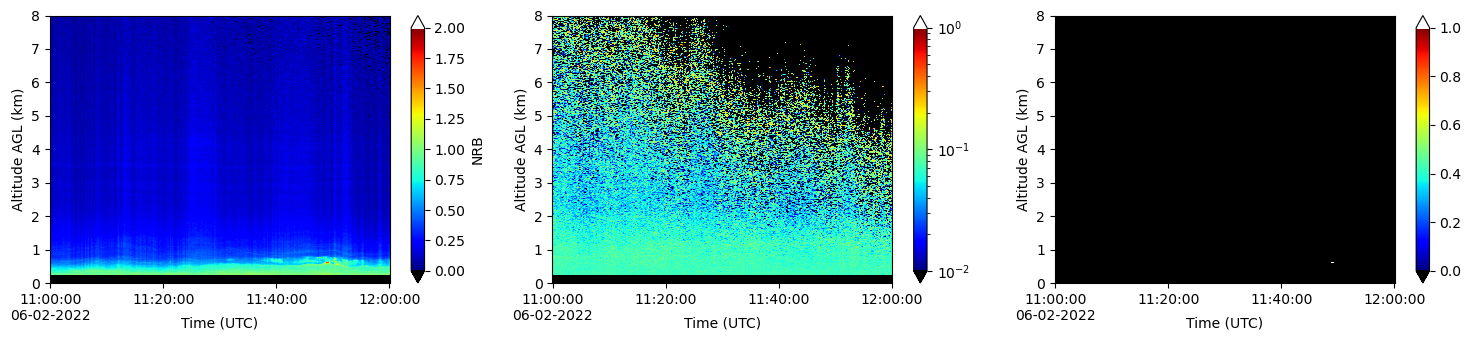

In [24]:
# Process MPL data

mpl_data, cloud_mask, cloud_free_column, high_snr_depol, fig1, axs1 \
    = tracer_avp_processing.process_mpl_data(start_time, end_time,                             # Input start_time and end_time
                                                input_folder = arm_mpl_dir_path,               # Input raw mpl file folder path
                                                ap_file = arm_mpl_afterpulse_binary_path,      # Input afterpulse binary path
                                                ov_file = arm_mpl_overlap_binary_path,         # Input overlap binary path
                                                dt_file = arm_mpl_deadtime_binary_path,        # Input deadtime binary path
                                                suffix = '*.mpl',                              # ARM MPL also produces '.mpl2' files, likely from the wide-angle receiver. Here we only use '.mpl' and ignore '.mpl2'.
                                                time_resolution = 10, mov_avg_win = None,      # We match the raw data resolution here at 10 seconds, aligning the data to a regular temporal grid. Therefore, no moving average is needed. 
                                                                                               # However, if downsampling, for example, to 60 seconds, a moving average window of 6 should be applied to preserve temporal representativeness.
                                                                                               # By the way, the interpolation step also detects gaps in the data and represent them as nan.
                                                scale_num = 30,                                # number of continuous wavelet transform (CWT) scales. Sets the largest wavelet window (~30 range bins)
                                                length_treshold = 25,                          # minimum length (in range bins) a CWT ridge/trough must persist before it can qualify as a cloud edge
                                                value_treshold = 1.5,                          # minimum absolute CWT-coefficient of a ridge/trough at the coarsest scale; filters out weak, noisy features
                                                edge_treshold = 1.4,                           # NRB (or smoothed NRB) amplitude cutoff used to trim the coarse CWT boundaries to their exact bottoms/tops
                                                contain_cloud_treshold = 1.45,                 # NRB level that must be met by at least a short run of bins to declare that “there is cloud between two candidate bottoms”
                                                cloud_pixel_number_treshold = 1,               # how many consecutive bins must exceed contain_cloud_treshold to bridge a gap (1 keeps everything, 2+ removes speckle)
                                                snr_treshold = 5,                              # Quality screen on raw MPL data. Any gate whose signal-to-noise ratio is < 5 is set to NaN. That prevents low-quality bins from influencing later steps (wavelet transform, cloud finding, retrievals).
                                                not_a_cloud_treshold = 1.4,                    # Last-pass intensity veto.  After the wavelet/CWT logic has built a tentative cloud mask, every bin whose (smoothed) NRB is still < 1.4 is forced to “not-cloud.” 
                                                find_cloud_range = calibration_range,          # Highest altitude to find cloud. Only do cloud masking here below calibration_range (8 km).
                                                blind_zone = 0.25,                             # MPL has a blind zone of about 250 m near the ground.
                                                fig = None, axs = None, figsize = (15,3.5), plot_range_max = 8,   # if None is supplied to fig and axs, this function will create a figure and axs, which are then returned.
                                                savefig = True, showplot = True, output_folder = output_dir_path) # set other behavior of this function.